In [1]:
from ase.io import read
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

In [4]:
# Visualize the simulation box using py3Dmol
from ase.io import Trajectory

traj_path = "/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/nvt_init_frame/student_NaPF6_298K/na_pf6_dme_298K_0.1M_student/na_pf6_dme_298K_0.1M_student.traj"

with Trajectory(traj_path, mode='r') as traj:
    frame_count = len(traj)
    print(f"Number of frames in trajectory: {frame_count}")
    base_structure = traj[-1]
base_structure.arrays

Number of frames in trajectory: 1


{'numbers': array([1, 6, 8, ..., 9, 9, 9], shape=(2016,)),
 'positions': array([[ 14.40954069,  10.61652072, -10.39589355],
        [ 14.92744174,  10.80159155,  -9.38890744],
        [ 15.15307268,   9.50060853,  -8.81654296],
        ...,
        [-10.35892025,  13.11585304,  34.74801104],
        [ -9.55435772,  14.14374132,  32.83163567],
        [ -8.27546697,  13.98430946,  34.92725644]], shape=(2016, 3)),
 'initial_magmoms': array([0., 0., 0., ..., 0., 0., 0.], shape=(2016,)),
 'initial_charges': array([0., 0., 0., ..., 0., 0., 0.], shape=(2016,))}

In [1]:
# Visualize the simulation box using py3Dmol
from ase.io import Trajectory

traj_path = "/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/nvt_init_frame/scale_up_boxes/match_exp_density/teacher_NaPF6_323K_0.5M/na_pf6_dme_323K_0.5M_teacher/na_pf6_dme_323K_0.5M_teacher.traj"

with Trajectory(traj_path, mode='r') as traj:
    frame_count = len(traj)
    print(f"Number of frames in trajectory: {frame_count}")
    base_structure = traj[-1]

# Remove "momenta" if present in arrays
base_structure.arrays.pop("momenta", None)

# === Wrap coordinates into the simulation box (PBC) ===
base_structure.wrap()

# Use py3Dmol to visualize the molecule in the box
import py3Dmol
from ase.io import write
import io

# Export the base_structure to xyz in memory
xyz_buf = io.StringIO()
write(xyz_buf, base_structure, format='xyz')
xyz_str = xyz_buf.getvalue()

# Set up the 3D viewer and show the periodic box
view = py3Dmol.view(width=600, height=400)
view.addModel(xyz_str, 'xyz')
view.setStyle({'stick': {}})
# Draw simulation box (unit cell)
cell = base_structure.get_cell()
a, b, c = cell[0], cell[1], cell[2]
origin = [0, 0, 0]

# Draw the 12 edges of the box
def draw_box(view, origin, a, b, c, color='#888888'):
    # 8 vertices
    pts = [
        origin,
        origin + a,
        origin + b,
        origin + c,
        origin + a + b,
        origin + a + c,
        origin + b + c,
        origin + a + b + c,
    ]
    # Edges (as joes)
    edges = [
        (0,1),(0,2),(0,3),
        (1,4),(1,5),
        (2,4),(2,6),
        (3,5),(3,6),
        (4,7),(5,7),(6,7)
    ]
    for i,j in edges:
        view.addLine({'start':{'x':float(pts[i][0]),'y':float(pts[i][1]),'z':float(pts[i][2])},
                      'end':{'x':float(pts[j][0]),'y':float(pts[j][1]),'z':float(pts[j][2])},
                      'color':color, 'linewidth':2})

draw_box(view, origin, a, b, c)
view.zoomTo()
view.show()

Number of frames in trajectory: 1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [3]:
base_structure.get_potential_energy()

-1494965.2717799728

In [5]:
def vis_traj(traj_path):
    # Path to trajectory file
    # traj_path = "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_cspf6_pfactor_0.1_1fs_mask_t/md_omol_cspf6_pfactor_0.1_1fs_mask_t.traj"

    # Load trajectory (all frames)
    images = read(traj_path, index=":")

    print(len(images))

    # Extract potential energies from all images
    potential_energies = [img.get_calculator().get_potential_energy() for img in images]
    # Plot potential energy vs. frame index
    plt.figure(figsize=(8, 4))
    plt.plot(potential_energies, marker='o', linestyle='-', markersize=2)
    plt.xlabel('Frame')
    plt.ylabel('Potential Energy (eV)')
    plt.title('Potential Energy vs. Frame (every 10fs)'+ os.path.basename(traj_path))
    plt.tight_layout()
    plt.show()

In [6]:
list_of_traj = [
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_cspf6_pfactor_0.1_1fs_mask_t/md_omol_cspf6_pfactor_0.1_1fs_mask_t.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_lipf6_pfactor_0.1_1fs_mask_t/md_omol_lipf6_pfactor_0.1_1fs_mask_t.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_naotf_diglyme_1m_s1p1/md_omol_naotf_diglyme_1m_s1p1.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_naotf_dme_s1p1_omol/md_omol_naotf_dme_s1p1_omol.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_naotf_pc_1m_s1p1/md_omol_naotf_pc_1m_s1p1.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_napf6_diethyleneglycol_pfactor_0.1_1fs_mask_t/md_omol_napf6_diethyleneglycol_pfactor_0.1_1fs_mask_t.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_napf6_dimethylcarbonate_pfactor_0.1_1fs_mask_t_re2/md_omol_napf6_dimethylcarbonate_pfactor_0.1_1fs_mask_t_re2.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_napf6_ethylene_carbonate_pfactor_0.1_1fs_mask_t_re2/md_omol_napf6_ethylene_carbonate_pfactor_0.1_1fs_mask_t_re2.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_napf6_propylene_carbonate_pfactor_0.1_1fs_mask_t_re1_s1p1/md_omol_napf6_propylene_carbonate_pfactor_0.1_1fs_mask_t_re1_s1p1.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_napf6_propylene_carbonate_pfactor_0.1_1fs_mask_t_re3_s1p1/md_omol_napf6_propylene_carbonate_pfactor_0.1_1fs_mask_t_re3_s1p1.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_napf6_tetrahydrofuran_pfactor_0.1_1fs_mask_t_re2/md_omol_napf6_tetrahydrofuran_pfactor_0.1_1fs_mask_t_re2.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_napf6_tgdme_1m_s1p1/md_omol_napf6_tgdme_1m_s1p1.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_napf6_tgdme_1m_s1p1_re2/md_omol_napf6_tgdme_1m_s1p1_re2.traj",
    "/global/homes/y/yuejian/project/MLFF-distill/yuejian/MD_data_rest/md_omol_natfsi_dme_s1p1/md_omol_natfsi_dme_s1p1.traj"
]

53930


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


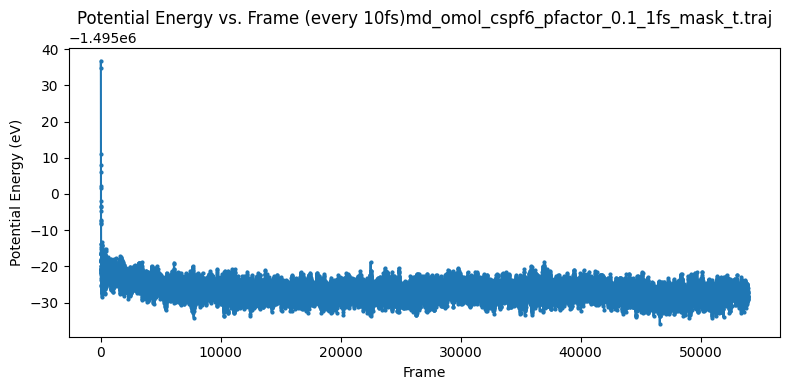

In [7]:
vis_traj(list_of_traj[0])

50787


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


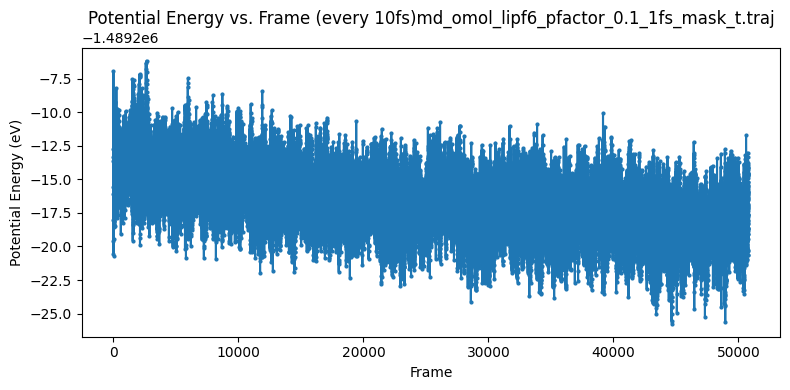

In [8]:
vis_traj(list_of_traj[1])

47149


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


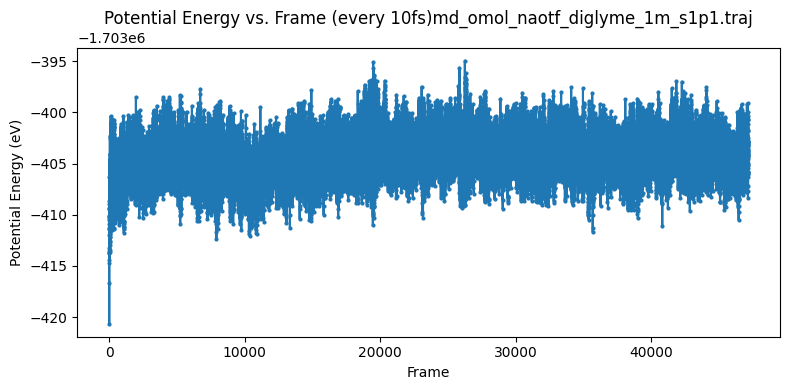

In [9]:
vis_traj(list_of_traj[2])

53368


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


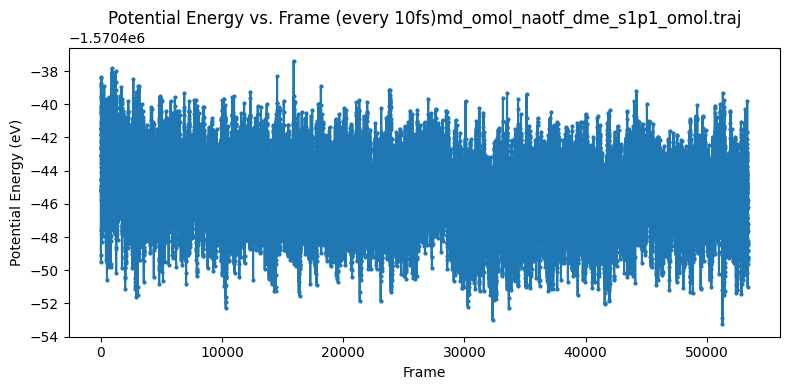

In [10]:
vis_traj(list_of_traj[3])

51218


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


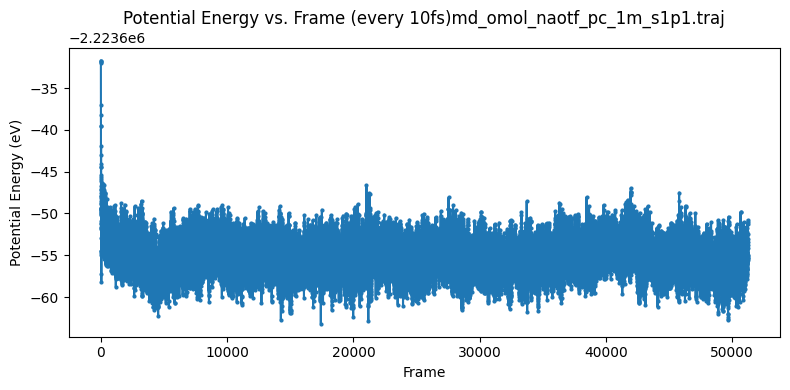

In [11]:
vis_traj(list_of_traj[4])

38342


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


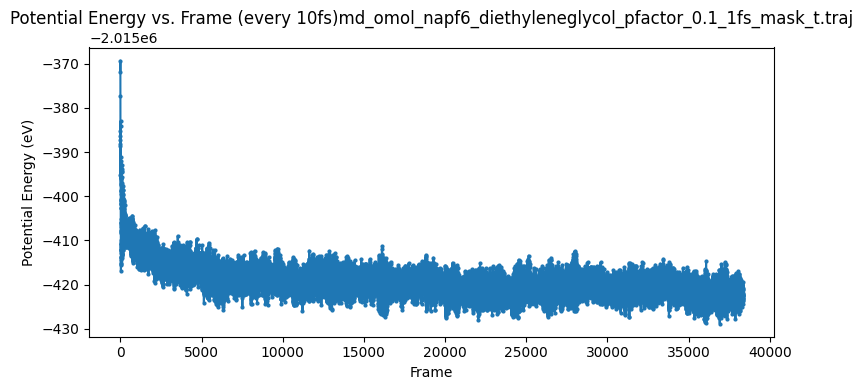

In [12]:
vis_traj(list_of_traj[5])

57574


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


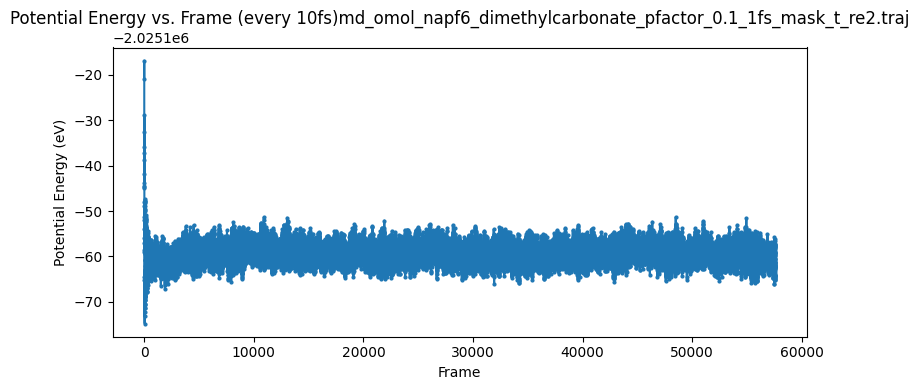

In [13]:
vis_traj(list_of_traj[6])

53291


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


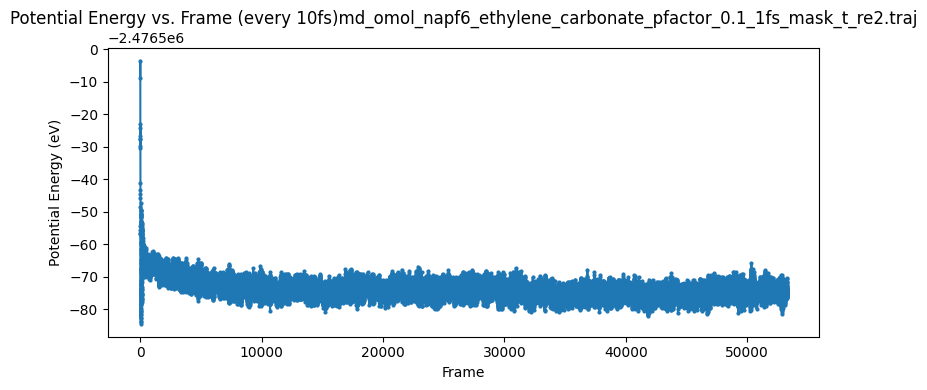

In [14]:
vis_traj(list_of_traj[7])

52400


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


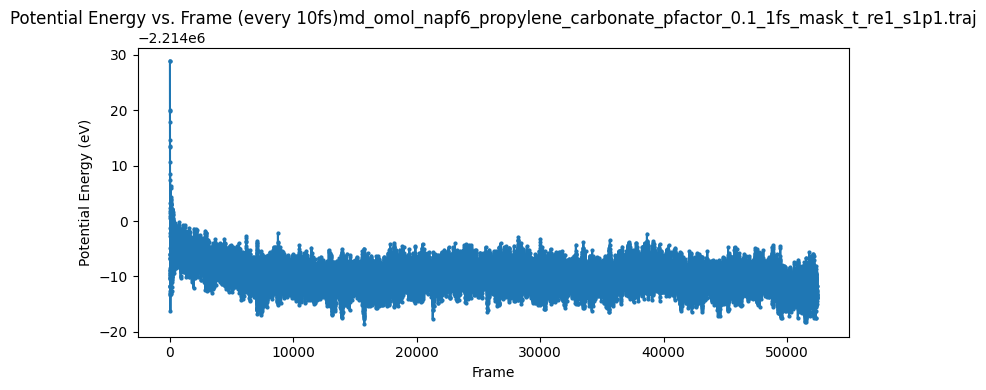

In [15]:
vis_traj(list_of_traj[8])

52364


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


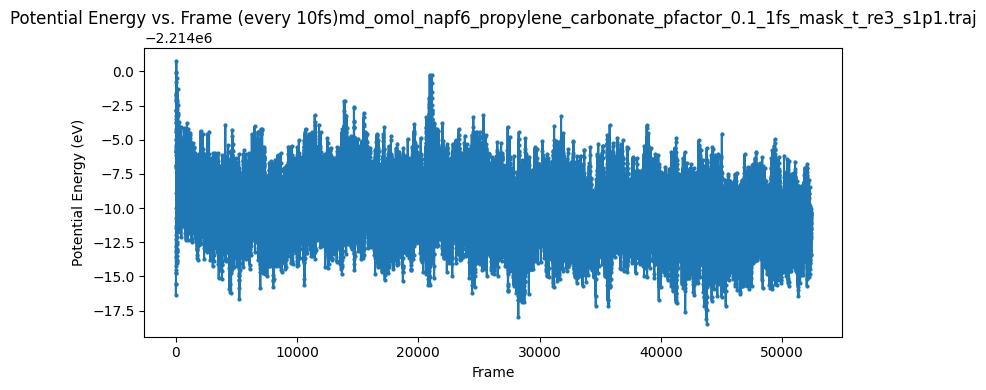

In [16]:
vis_traj(list_of_traj[9])

50179


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


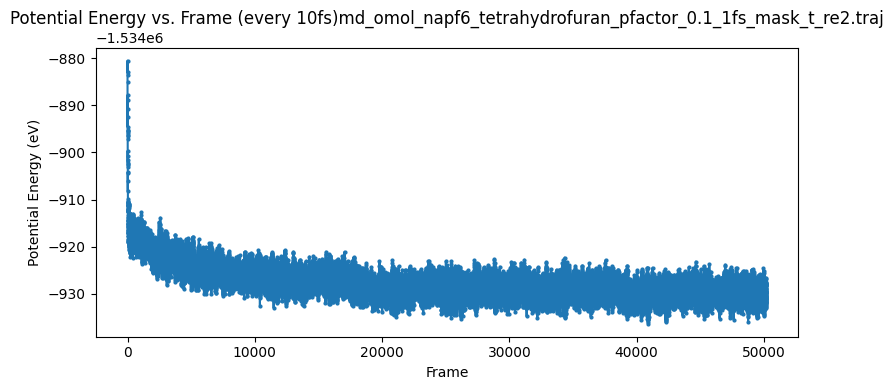

In [18]:
vis_traj(list_of_traj[10])

43877


/tmp/ipykernel_1222780/1772667298.py:11: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]


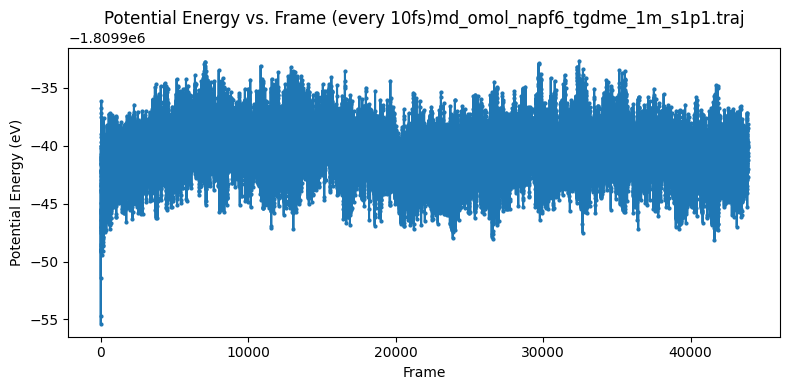

In [17]:
vis_traj(list_of_traj[11])

/tmp/ipykernel_1470622/1946054267.py:2: FutureWarning: Please use atoms.calc
  potential_energies = [img.get_calculator().get_potential_energy() for img in images]
/tmp/ipykernel_1470622/1946054267.py:3: FutureWarning: Please use atoms.calc
  potential_energies_n = [img.get_calculator().get_potential_energy() for img in images_n]


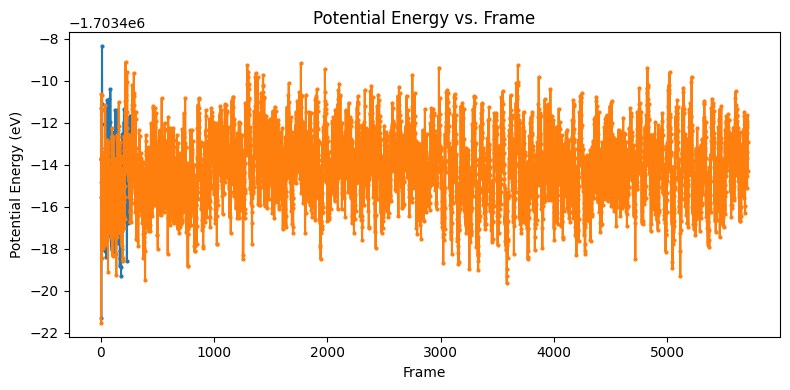

In [6]:
# Extract potential energies from all images
potential_energies = [img.get_calculator().get_potential_energy() for img in images]
potential_energies_n = [img.get_calculator().get_potential_energy() for img in images_n]
# Plot potential energy vs. frame index
plt.figure(figsize=(8, 4))
plt.plot(potential_energies, marker='o', linestyle='-', markersize=2)
plt.plot(potential_energies_n, marker='o', linestyle='-', markersize=2)
plt.xlabel('Frame')
plt.ylabel('Potential Energy (eV)')
plt.title('Potential Energy vs. Frame')
plt.tight_layout()
plt.show()

In [2]:
grid_cell_atom_count = torch.load("/global/homes/y/yuejian/project/MLFF-distill/yuejian/test/grid_cell_atom_count.pt")
source_atom_grid_id = torch.load("/global/homes/y/yuejian/project/MLFF-distill/yuejian/test/source_atom_grid_id.pt")

In [6]:
grid_cell_atom_count.shape,source_atom_grid_id

(torch.Size([8000]),
 tensor([ 9223372036854772119, -9223372036854775497, -9223372036854771497,
          ...,  9223372036854774104, -9223372036854773512,
         -9223372036854769512], device='cuda:0'))

In [2]:
grid_cell_atom_count.index_add_(
    0, source_atom_grid_id, torch.ones_like(source_atom_grid_id)
)

/pytorch/aten/src/ATen/native/cuda/Indexing.cu:934: indexFuncLargeIndex: block: [299,0,0], thread: [2,0,0] Assertion `dstIndex < dstAddDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:934: indexFuncLargeIndex: block: [299,0,0], thread: [5,0,0] Assertion `dstIndex < dstAddDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:934: indexFuncLargeIndex: block: [299,0,0], thread: [8,0,0] Assertion `dstIndex < dstAddDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:934: indexFuncLargeIndex: block: [299,0,0], thread: [11,0,0] Assertion `dstIndex < dstAddDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:934: indexFuncLargeIndex: block: [299,0,0], thread: [14,0,0] Assertion `dstIndex < dstAddDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:934: indexFuncLargeIndex: block: [299,0,0], thread: [17,0,0] Assertion `dstIndex < dstAddDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:934: indexFuncLargeIndex: block: [299,

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
